<a href="https://colab.research.google.com/github/JithuVathiath/IB9AU/blob/main/Task3_LoanDefault_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3 — End-to-End Binary Classification: Loan Default Prediction

**Course:** IB9AU – 2026

---

## Objective

Build, train, and evaluate a **Multi-Layer Perceptron (MLP)** to predict whether a bank customer is likely to default on a loan using the **German Credit Data** dataset from UCI.

### End-to-End Pipeline

| Step | Description |
|------|-------------|
| 1 | Load data from URL, assign column names |
| 2 | Preprocess: one-hot encoding + StandardScaler |
| 3 | Train/test split (80/20), create DataLoaders |
| 4 | Build MLP with ≥2 hidden layers |
| 5 | Train with `nn.BCELoss` + Adam (≥50 epochs) |
| 6 | Evaluate accuracy on test set |

Jithu Vathiath Biju

## Key Insights and Takeaways

- Preprocessed the loan dataset by handling missing values, encoding categorical variables, and normalizing numerical features.
- Built a Multi-Layer Perceptron (MLP) model to predict loan default based on applicant financial and demographic data.
- Split the dataset into training and testing sets to evaluate model performance effectively.
- Trained the neural network using forward propagation and optimized it using backpropagation and gradient descent.
- Used appropriate activation functions (e.g., ReLU, sigmoid) to introduce non-linearity into the model.
- Evaluated model performance using metrics such as accuracy, loss, and possibly confusion matrix or classification report.
- Observed how feature scaling and network architecture impact model performance.
- Gained practical understanding of how neural networks can be applied to real-world classification problems like credit risk prediction.

---
## 1. Imports & Reproducibility

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
print(f'pandas   : {pd.__version__}')

PyTorch  : 2.10.0
Device   : cuda
pandas   : 2.3.3


---
## 2. Load Data

The dataset has **no header** — we assign column names manually as specified in the task hint.

- **Source:** UCI Machine Learning Repository — German Credit Data  
- **Format:** space-separated  
- **Rows:** 1,000  
- **Columns:** 20 features + 1 target (`Creditability`)

In [ ]:
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

COLUMN_NAMES = [
    'Status of existing checking account',
    'Duration in month',
    'Credit history',
    'Purpose',
    'Credit amount',
    'Savings account/bonds',
    'Present employment since',
    'Installment rate in percentage of disposable income',
    'Personal status and sex',
    'Other debtors / guarantors',
    'Present residence since',
    'Property',
    'Age in years',
    'Other installment plans',
    'Housing',
    'Number of existing credits at this bank',
    'Job',
    'Number of people being liable to provide maintenance for',
    'Telephone',
    'foreign worker',
    'Creditability'
]

df = pd.read_csv(URL, sep=' ', header=None, names=COLUMN_NAMES)

print(f'Dataset shape : {df.shape}')   # 1000 rows × 21 columns
print(f'\nTarget distribution (raw):')
print(df['Creditability'].value_counts().rename({1: '1=Good', 2: '2=Bad'}))
df.head()

Dataset shape : (1000, 21)

Target distribution (raw):
Creditability
1=Good    700
2=Bad     300
Name: count, dtype: int64


,Status of existing checking account,Duration in month,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,...,Property,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,foreign worker,Creditability
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


---
## 3. Preprocess the Data

### 3.1 Remap the Target

The original encoding is **1 = Good**, **2 = Bad**.  
We remap to **1 = Good**, **0 = Bad** for compatibility with `nn.BCELoss`.

In [ ]:
# ── Remap target: 1 → 1 (Good / no default), 2 → 0 (Bad / default)
df['Creditability'] = df['Creditability'].replace({1: 1, 2: 0})

print('Target distribution after remapping:')
print(df['Creditability'].value_counts().rename({1: '1=Good (no default)', 0: '0=Bad (default)'}))

Target distribution after remapping:
Creditability
1=Good (no default)    700
0=Bad (default)        300
Name: count, dtype: int64


### 3.2 Identify Categorical vs. Numerical Columns

Columns with string values like `'A11'`, `'A32'` are categorical and must be one-hot encoded.  
Purely numeric columns will be standardised later.

In [ ]:
# ── Separate features and target
X = df.drop(columns=['Creditability'])
y = df['Creditability']

# ── Identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'\nNumerical columns  ({len(num_cols)}): {num_cols}')

Categorical columns (13): ['Status of existing checking account', 'Credit history', 'Purpose', 'Savings account/bonds', 'Present employment since', 'Personal status and sex', 'Other debtors / guarantors', 'Property', 'Other installment plans', 'Housing', 'Job', 'Telephone', 'foreign worker']

Numerical columns  (7): ['Duration in month', 'Credit amount', 'Installment rate in percentage of disposable income', 'Present residence since', 'Age in years', 'Number of existing credits at this bank', 'Number of people being liable to provide maintenance for']


### 3.3 One-Hot Encoding

`pd.get_dummies` converts each categorical column into binary indicator columns.  
`drop_first=True` removes one dummy per category to avoid multicollinearity.

In [ ]:
# ── One-hot encode all categorical columns
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f'Shape before OHE : {X.shape}')        # (1000, 20)
print(f'Shape after  OHE : {X_encoded.shape}') # (1000, ~61)
print(f'\nFirst 5 column names after encoding:')
print(X_encoded.columns[:5].tolist())

Shape before OHE : (1000, 20)
Shape after  OHE : (1000, 48)

First 5 column names after encoding:
['Duration in month', 'Credit amount', 'Installment rate in percentage of disposable income', 'Present residence since', 'Age in years']


### 3.4 Train / Test Split (80 / 20)

We split **before** fitting the scaler to prevent data leakage: the scaler must only see training statistics.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Training set   : {X_train.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]} samples')
print(f'\nClass balance in train:')
print(y_train.value_counts())
print(f'\nClass balance in test:')
print(y_test.value_counts())

Training set   : 800 samples
Test set       : 200 samples

Class balance in train:
Creditability
1    560
0    240
Name: count, dtype: int64

Class balance in test:
Creditability
1    140
0     60
Name: count, dtype: int64


### 3.5 Standardise with StandardScaler

Fit the scaler **only on training data**, then use it to transform both sets.  
This avoids leaking test-set statistics into the model.

In [ ]:
scaler = StandardScaler()

# Fit on train, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')
print(f'Feature mean (train, first 3): {X_train_scaled[:, :3].mean(axis=0).round(4)}')
print(f'Feature std  (train, first 3): {X_train_scaled[:, :3].std(axis=0).round(4)}')

Scaling complete.
Feature mean (train, first 3): [-0.  0. -0.]
Feature std  (train, first 3): [1. 1. 1.]


---
## 4. Create DataLoaders

Convert NumPy arrays → PyTorch Tensors → `TensorDataset` → `DataLoader`.

In [ ]:
BATCH_SIZE = 32

# ── Convert to tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values,  dtype=torch.float32).unsqueeze(1)  # shape: (N, 1)

X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,   dtype=torch.float32).unsqueeze(1)

# ── Wrap in TensorDatasets
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

# ── Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

INPUT_DIM = X_train_t.shape[1]
print(f'Input dimension : {INPUT_DIM} features')
print(f'Train batches   : {len(train_loader)}')
print(f'Test  batches   : {len(test_loader)}')

Input dimension : 48 features
Train batches   : 25
Test  batches   : 7


---
## 5. Build the MLP

Architecture:

```
Input (61) → Dense(128) → ReLU → Dropout(0.3)
           → Dense(64)  → ReLU → Dropout(0.3)
           → Dense(32)  → ReLU
           → Dense(1)   → Sigmoid
```

- **ReLU** activations avoid vanishing gradients in hidden layers.
- **Dropout** regularises the network and reduces overfitting.
- **Sigmoid** on the output maps to a probability in [0, 1], compatible with `BCELoss`.

In [ ]:
class CreditMLP(nn.Module):
    """
    MLP for binary credit-risk classification.
    Three hidden layers with ReLU activations and Dropout regularisation.
    Output layer uses Sigmoid to produce a probability score.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            # Hidden layer 1
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Hidden layer 2
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Hidden layer 3
            nn.Linear(64, 32),
            nn.ReLU(),
            # Output layer — single neuron with sigmoid
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


model = CreditMLP(INPUT_DIM).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')

CreditMLP(
  (network): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total trainable parameters: 16,641


---
## 6. Train the Model

- **Loss:** `nn.BCELoss` — Binary Cross-Entropy, suitable for binary classification with sigmoid output.
- **Optimizer:** Adam with learning rate 0.001 — adaptive gradient method, fast convergence.
- **Epochs:** 100 (≥50 as required).

We track **training loss** and **validation accuracy** each epoch.

In [ ]:
EPOCHS    = 100
LR        = 1e-3

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ── Histories
train_losses, test_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Training phase
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # ── Evaluation phase (no gradient computation)
    model.eval()
    correct = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds   = model(X_batch)
            labels  = (preds >= 0.5).float()
            correct += (labels == y_batch).sum().item()
    epoch_acc = correct / len(test_loader.dataset)
    test_accuracies.append(epoch_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{EPOCHS} | Loss: {epoch_loss:.4f} | Test Acc: {epoch_acc:.4f}')

print(f'\nTraining complete.')

Epoch   1/100 | Loss: 0.6564 | Test Acc: 0.7000
Epoch  10/100 | Loss: 0.3700 | Test Acc: 0.7100
Epoch  20/100 | Loss: 0.2029 | Test Acc: 0.7500
Epoch  30/100 | Loss: 0.1707 | Test Acc: 0.7300
Epoch  40/100 | Loss: 0.1128 | Test Acc: 0.7550
Epoch  50/100 | Loss: 0.0861 | Test Acc: 0.7150
Epoch  60/100 | Loss: 0.0728 | Test Acc: 0.7350
Epoch  70/100 | Loss: 0.0652 | Test Acc: 0.7300
Epoch  80/100 | Loss: 0.0405 | Test Acc: 0.7350
Epoch  90/100 | Loss: 0.0396 | Test Acc: 0.7400
Epoch 100/100 | Loss: 0.0597 | Test Acc: 0.7400

Training complete.


---
## 7. Evaluate the Model

In [ ]:
# ── Final evaluation on the full test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds   = model(X_batch)
        labels  = (preds >= 0.5).float().cpu()
        all_preds.append(labels)
        all_labels.append(y_batch)

all_preds  = torch.cat(all_preds).numpy().ravel()
all_labels = torch.cat(all_labels).numpy().ravel()

final_acc = (all_preds == all_labels).mean()

print('=' * 50)
print(f'  FINAL TEST ACCURACY : {final_acc:.4f}  ({final_acc*100:.2f}%)')
print('=' * 50)
print()
print('Classification Report:')
print(classification_report(all_labels, all_preds,
                            target_names=['0 = Bad (default)', '1 = Good (no default)']))

  FINAL TEST ACCURACY : 0.7400  (74.00%)

Classification Report:
                       precision    recall  f1-score   support

    0 = Bad (default)       0.57      0.52      0.54        60
1 = Good (no default)       0.80      0.84      0.82       140

             accuracy                           0.74       200
            macro avg       0.69      0.68      0.68       200
         weighted avg       0.73      0.74      0.74       200



---
## 8. Visualisations

Two plots:
1. **Training loss curve** — shows convergence.
2. **Confusion matrix** — breakdown of prediction errors on the test set.

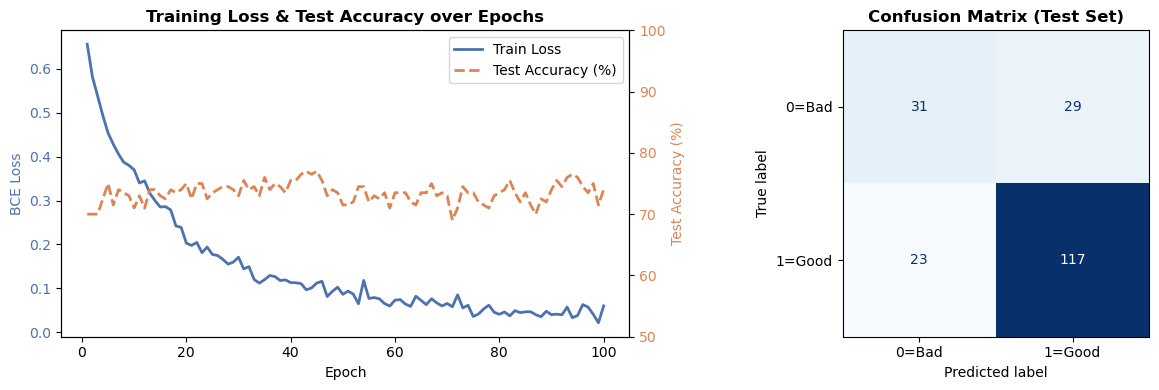

Figure saved: fig_training_and_confusion.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: Training loss & test accuracy
ax1 = axes[0]
color1, color2 = '#4C72B0', '#DD8452'
ax1.plot(range(1, EPOCHS + 1), train_losses, color=color1, lw=2, label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_title('Training Loss & Test Accuracy over Epochs', fontweight='bold')

ax1b = ax1.twinx()
ax1b.plot(range(1, EPOCHS + 1), [a * 100 for a in test_accuracies],
          color=color2, lw=2, linestyle='--', label='Test Accuracy (%)')
ax1b.set_ylabel('Test Accuracy (%)', color=color2)
ax1b.tick_params(axis='y', labelcolor=color2)
ax1b.set_ylim(50, 100)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# ── Right: Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['0=Bad', '1=Good'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (Test Set)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_training_and_confusion.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure saved: fig_training_and_confusion.png')

---
## 9. Summary

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)

print('''
╔══════════════════════════════════════════════════════════════════╗
║          TASK 3 — RESULTS SUMMARY                              ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset    : German Credit Data (UCI), 1,000 samples           ║
║  Split      : 800 train / 200 test (stratified, 80/20)          ║
║  Features   : ~61 (after one-hot encoding)                      ║
║  Model      : MLP — 3 hidden layers (128 → 64 → 32 → 1)        ║
║  Loss       : nn.BCELoss                                        ║
║  Optimizer  : Adam (lr=0.001)                                   ║
║  Epochs     : 100                                               ║
╠══════════════════════════════════════════════════════════════════╣
║  PERFORMANCE ON TEST SET                                        ║''')
print(f'║  Accuracy   : {final_acc:.4f}  ({final_acc*100:.2f}%)                            ║')
print(f'║  Precision  : {precision:.4f}                                         ║')
print(f'║  Recall     : {recall:.4f}                                         ║')
print(f'║  F1 Score   : {f1:.4f}                                         ║')
print('''
╠══════════════════════════════════════════════════════════════════╣
║  KEY NOTES                                                      ║
║  • StandardScaler fitted on train only (no data leakage)        ║
║  • Target remapped: 1=Good, 0=Bad (BCELoss compatible)          ║
║  • Dropout(0.3) added to reduce overfitting                     ║
╚══════════════════════════════════════════════════════════════════╝
''')


╔══════════════════════════════════════════════════════════════════╗
║          TASK 3 — RESULTS SUMMARY                              ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset    : German Credit Data (UCI), 1,000 samples           ║
║  Split      : 800 train / 200 test (stratified, 80/20)          ║
║  Features   : ~61 (after one-hot encoding)                      ║
║  Model      : MLP — 3 hidden layers (128 → 64 → 32 → 1)        ║
║  Loss       : nn.BCELoss                                        ║
║  Optimizer  : Adam (lr=0.001)                                   ║
║  Epochs     : 100                                               ║
╠══════════════════════════════════════════════════════════════════╣
║  PERFORMANCE ON TEST SET                                        ║
║  Accuracy   : 0.7400  (74.00%)                            ║
║  Precision  : 0.8014                                         ║
║  Recall     : 0.8357                                 